1. Load and Basic Information

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load data
df_credit = pd.read_csv('../data/raw/creditcard.csv')

print("Dataset Shape:", df_credit.shape)
print("\nFirst 5 rows:")
df_credit.head()

Dataset Shape: (284807, 31)

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


2. Data Quality Check

In [2]:
# Check for missing values
print("Missing Values:")
print(df_credit.isnull().sum().sum())  # Should be 0

# Check data types
print("\nData Types:")
print(df_credit.dtypes.value_counts())

# Basic statistics
print("\nBasic Statistics:")
df_credit.describe()

Missing Values:
0

Data Types:
float64    30
int64       1
Name: count, dtype: int64

Basic Statistics:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


3. Target Variable

Class Distribution:
Legitimate (0): 284,315 (99.8273%)
Fraud (1): 492 (0.1727%)


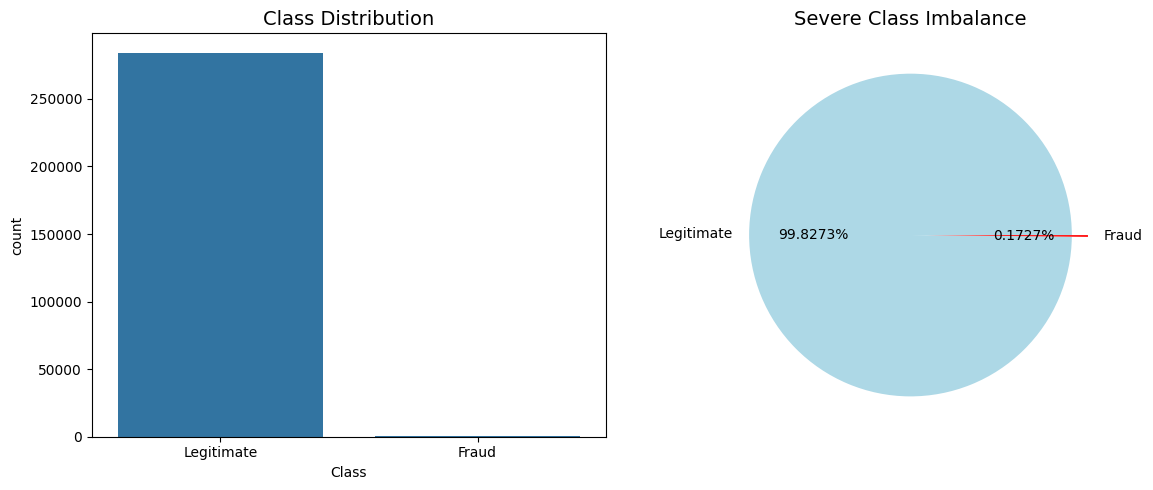

In [3]:
# Class distribution
fraud_counts = df_credit['Class'].value_counts()
fraud_percent = df_credit['Class'].value_counts(normalize=True) * 100

print("Class Distribution:")
print(f"Legitimate (0): {fraud_counts[0]:,} ({fraud_percent[0]:.4f}%)")
print(f"Fraud (1): {fraud_counts[1]:,} ({fraud_percent[1]:.4f}%)")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df_credit, x='Class', ax=axes[0])
axes[0].set_title('Class Distribution', fontsize=14)
axes[0].set_xticklabels(['Legitimate', 'Fraud'])

axes[1].pie(fraud_counts, labels=['Legitimate', 'Fraud'], autopct='%1.4f%%',
            colors=['lightblue', 'red'], explode=(0, 0.1))
axes[1].set_title('Severe Class Imbalance', fontsize=14)

plt.tight_layout()
plt.savefig('../data/processed/credit_class_distribution.png', dpi=100)
plt.show()

4.  Transaction Amount Analysis

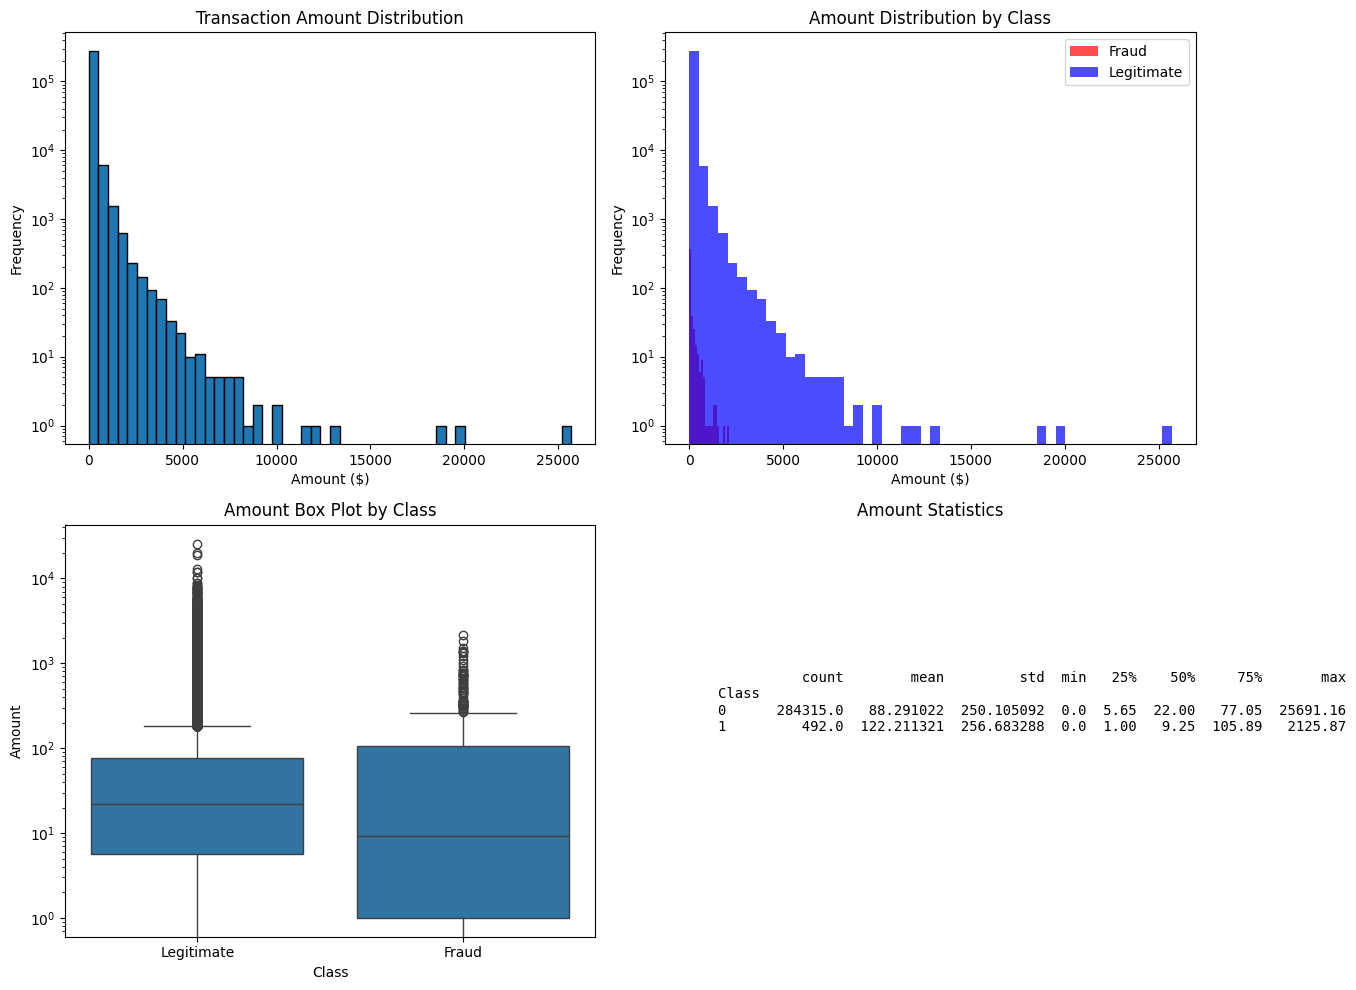


Amount Statistics by Class:
          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Amount distribution (log scale)
axes[0,0].hist(df_credit['Amount'], bins=50, edgecolor='black')
axes[0,0].set_title('Transaction Amount Distribution', fontsize=12)
axes[0,0].set_xlabel('Amount ($)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].set_yscale('log')

# Amount by class
fraud_amounts = df_credit[df_credit['Class']==1]['Amount']
legit_amounts = df_credit[df_credit['Class']==0]['Amount']

axes[0,1].hist(fraud_amounts, bins=20, alpha=0.7, label='Fraud', color='red')
axes[0,1].hist(legit_amounts, bins=50, alpha=0.7, label='Legitimate', color='blue')
axes[0,1].set_title('Amount Distribution by Class', fontsize=12)
axes[0,1].set_xlabel('Amount ($)')
axes[0,1].set_ylabel('Frequency')
axes[0,1].legend()
axes[0,1].set_yscale('log')

# Box plot
sns.boxplot(data=df_credit, x='Class', y='Amount', ax=axes[1,0])
axes[1,0].set_title('Amount Box Plot by Class', fontsize=12)
axes[1,0].set_xticklabels(['Legitimate', 'Fraud'])
axes[1,0].set_yscale('log')

# Statistics
stats = df_credit.groupby('Class')['Amount'].describe()
axes[1,1].axis('off')
axes[1,1].text(0.1, 0.5, str(stats), fontsize=10, family='monospace')
axes[1,1].set_title('Amount Statistics', fontsize=12)

plt.tight_layout()
plt.savefig('../data/processed/credit_amount_analysis.png', dpi=100)
plt.show()

print("\nAmount Statistics by Class:")
print(stats)

5. Time Analysis

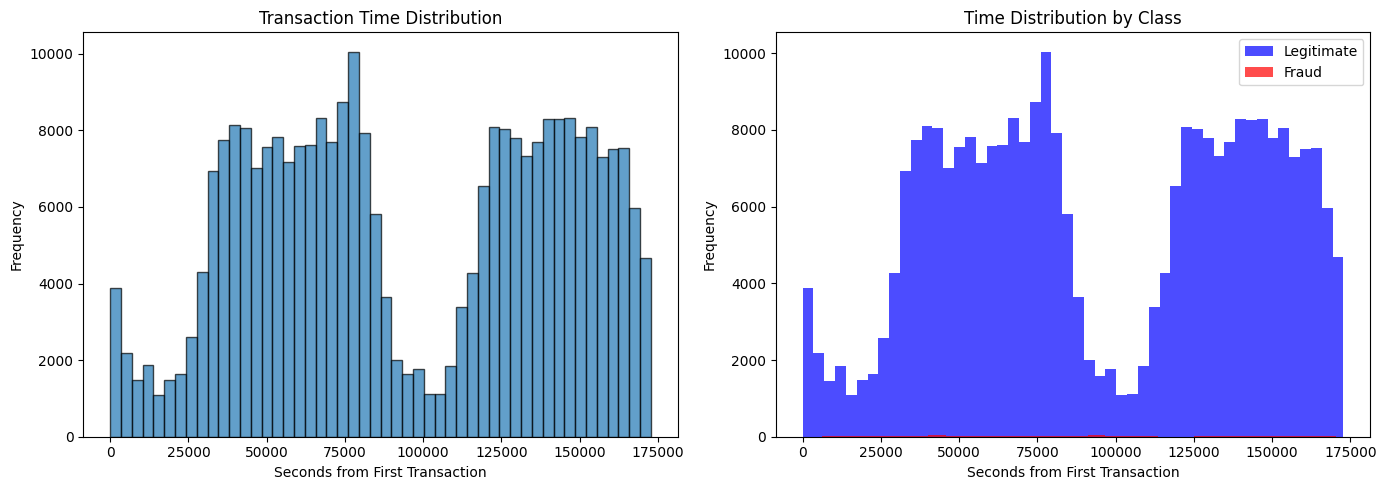

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Time distribution
axes[0].hist(df_credit['Time'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Transaction Time Distribution', fontsize=12)
axes[0].set_xlabel('Seconds from First Transaction')
axes[0].set_ylabel('Frequency')

# Time by class
axes[1].hist(df_credit[df_credit['Class']==0]['Time'], bins=50, alpha=0.7, 
             label='Legitimate', color='blue')
axes[1].hist(df_credit[df_credit['Class']==1]['Time'], bins=30, alpha=0.7,
             label='Fraud', color='red')
axes[1].set_title('Time Distribution by Class', fontsize=12)
axes[1].set_xlabel('Seconds from First Transaction')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/credit_time_analysis.png', dpi=100)
plt.show()

6.  Correlation with Target

Top 10 Features Correlated with Fraud:
Class    1.000000
V11      0.154876
V4       0.133447
V2       0.091289
V21      0.040413
V19      0.034783
V20      0.020090
V8       0.019875
V27      0.017580
V28      0.009536
Name: Class, dtype: float64

Bottom 10 Features Correlated with Fraud:
V9    -0.097733
V1    -0.101347
V18   -0.111485
V7    -0.187257
V3    -0.192961
V16   -0.196539
V10   -0.216883
V12   -0.260593
V14   -0.302544
V17   -0.326481
Name: Class, dtype: float64


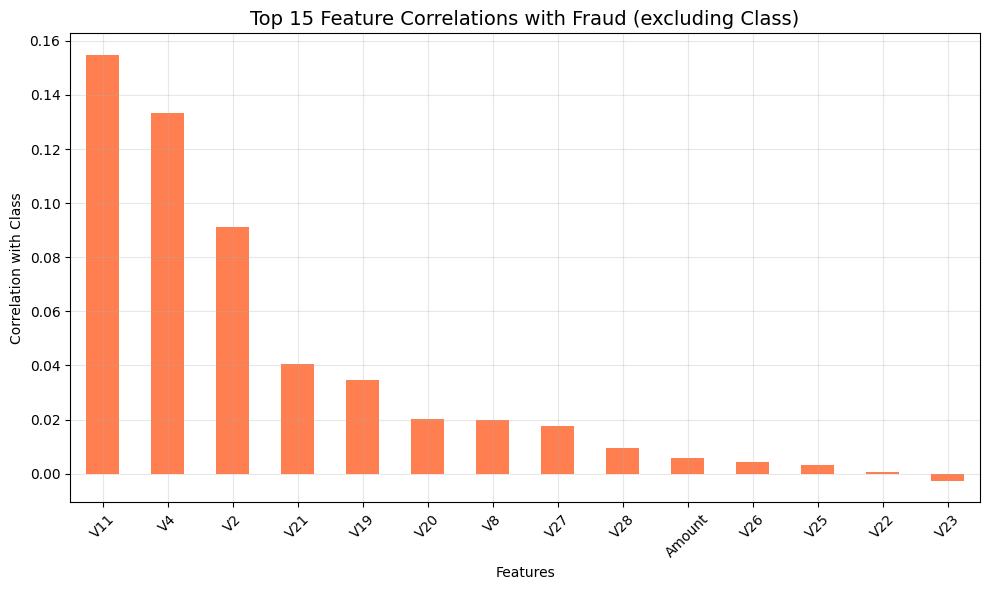

In [6]:
# Correlation with Class
correlations = df_credit.corr()['Class'].sort_values(ascending=False)

print("Top 10 Features Correlated with Fraud:")
print(correlations.head(10))
print("\nBottom 10 Features Correlated with Fraud:")
print(correlations.tail(10))

# Visualize top correlations
plt.figure(figsize=(10, 6))
correlations.head(15)[1:].plot(kind='bar', color='coral')
plt.title('Top 15 Feature Correlations with Fraud (excluding Class)', fontsize=14)
plt.xlabel('Features')
plt.ylabel('Correlation with Class')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../data/processed/credit_correlations.png', dpi=100)
plt.show()

7. Save Processed Data

In [7]:
# Save for modeling
df_credit.to_csv('../data/processed/creditcard_cleaned.csv', index=False)
print("Cleaned credit card data saved!")

Cleaned credit card data saved!
